In [2]:
from asmcmc.initialize import RandomLatticeInitializer, ColumnarLatticeInitializer, FrameInitializer
from asmcmc.metropolis import MetropolisCalculator
from asmcmc.potentials import GBQPotential, CACELLI_POTENTIAL
from asmcmc.measurements import (
    TrajectoryAnalyzer, 
    RadialDistributionFunction, 
    OrientationalCorrelationFunction, 
    HeatCapacity, 
    NematicOrderParameter, 
    AverageEnthalpy,
    BOLTZCONST
)

import pickle
import os
import json

import matplotlib.pyplot as plt
import numpy as np

from ase.db import connect
import ase.io

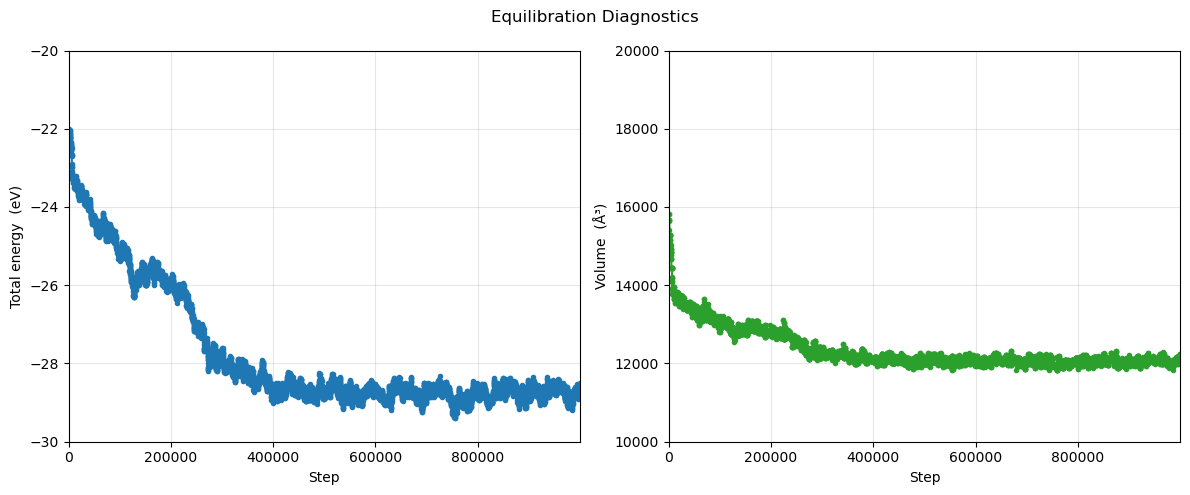

In [3]:
# Equilibration Diagnostics

steps, energy, vol = [], [], []
with connect("/home/lucas/Projects/cersonsky/asmcmc/results/validation/100.0_6.324209e-07/herringbone/equilibration.db") as db:
    for row in db.select():
        steps.append(row.step)
        energy.append(row.total_energy)
        vol.append(row.vol)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

MIN_STEP = 0
MAX_STEP = max(steps)

MIN_ENERGY = -30
MAX_ENERGY = -20

MIN_VOL = 10_000
MAX_VOL = 20_000


def fit_line(ax, x, y, xlim, ylim):
    """Fit a line to the points inside the (xlim, ylim) window and draw it.

    Masking against the same bounds used for the axes means the fit
    follows the plot window: change MIN_*/MAX_* and the line updates.
    """
    x, y = np.asarray(x), np.asarray(y)
    (xlo, xhi), (ylo, yhi) = xlim, ylim
    mask = (x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi)
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    xs = np.array([xlo, xhi])
    ax.plot(xs, slope * xs + intercept, color="black", ls="--",
            label=f"fit: {slope:.3g}·step + {intercept:.3g}")
    ax.legend()


axs[0].plot(steps, energy, marker=".")
axs[0].set_ylabel("Total energy  (eV)")
#fit_line(axs[0], steps, energy, (MIN_STEP, MAX_STEP), (MIN_ENERGY, MAX_ENERGY))

axs[1].plot(steps, vol, marker=".", color="tab:green")
axs[1].set_ylabel("Volume  (Å³)")
#fit_line(axs[1], steps, vol, (MIN_STEP, MAX_STEP), (MIN_VOL, MAX_VOL))

for ax in axs:
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

axs[0].set_xbound(MIN_STEP, max(steps))
axs[1].set_xbound(MIN_STEP, max(steps))

axs[0].set_ybound(MIN_ENERGY, MAX_ENERGY)
axs[1].set_ybound(MIN_VOL, MAX_VOL)


fig.suptitle("Equilibration Diagnostics")
fig.tight_layout()

fig.savefig("../results/validation/100.0_6.324209e-07/herringbone/equilibration_diagnostics.png", dpi=150)

plt.show()

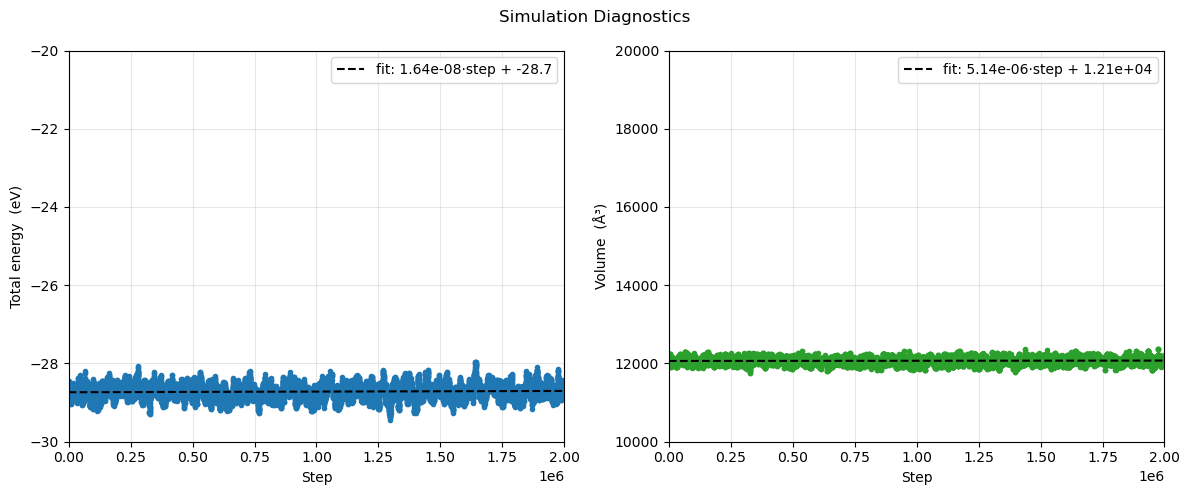

In [4]:
# Basic simulation diagnostics

steps, energy, vol = [], [], []
with connect("../results/validation/100.0_6.324209e-07/herringbone/simulation.db") as db:
    for row in db.select():
        steps.append(row.step)
        energy.append(row.total_energy)
        vol.append(row.vol)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
MAX_STEP = max(steps)


axs[0].plot(steps, energy, marker=".")
axs[0].set_ylabel("Total energy  (eV)")
fit_line(axs[0], steps, energy, (MIN_STEP, MAX_STEP), (MIN_ENERGY, MAX_ENERGY))

axs[1].plot(steps, vol, marker=".", color="tab:green")
axs[1].set_ylabel("Volume  (Å³)")
fit_line(axs[1], steps, vol, (MIN_STEP, MAX_STEP), (MIN_VOL, MAX_VOL))

for ax in axs:
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

axs[0].set_xbound(MIN_STEP, max(steps))
axs[1].set_xbound(MIN_STEP, max(steps))

axs[0].set_ybound(MIN_ENERGY, MAX_ENERGY)
axs[1].set_ybound(MIN_VOL, MAX_VOL)


fig.suptitle("Simulation Diagnostics")
fig.tight_layout()

fig.savefig("../results/validation/100.0_6.324209e-07/herringbone/simulation_diagnostics.png", dpi=150)

plt.show()

In [5]:
# Write simulation to .xyz file so that it can be visualized
# To perform the write, set WRITE_TO_XYZ = True

WRITE_TO_XYZ = False

if WRITE_TO_XYZ:
    traj = []

    with connect("../results/validation/100.0_6.324209e-07/herringbone/simulation.db") as db:
        for row in db.select():
            atoms = row.toatoms()
            atoms.new_array("c_q", np.asarray(row.data["c_q"]))
            atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
            atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for _ in atoms]))
            atoms.info["total_energy"] = row["total_energy"]

            traj.append(atoms)

    ase.io.write("../results/validation/100.0_6.324209e-07/herringbone/simulation.xyz", traj, format="extxyz")

In [6]:
# Write equilibration to .xyz file so that it can be visualized
# To perform the write, set WRITE_TO_XYZ = True

WRITE_TO_XYZ = False

if WRITE_TO_XYZ:
    eq_traj = []

    with connect("../results/validation/100.0_6.324209e-07/herringbone/equilibration.db") as db:
        for row in db.select():
            atoms = row.toatoms()
            atoms.new_array("c_q", np.asarray(row.data["c_q"]))
            atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
            atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for _ in atoms]))
            atoms.info["total_energy"] = row["total_energy"]

            eq_traj.append(atoms)

    ase.io.write("../results/validation/100.0_6.324209e-07/herringbone/equilibration.xyz", eq_traj, format="extxyz")

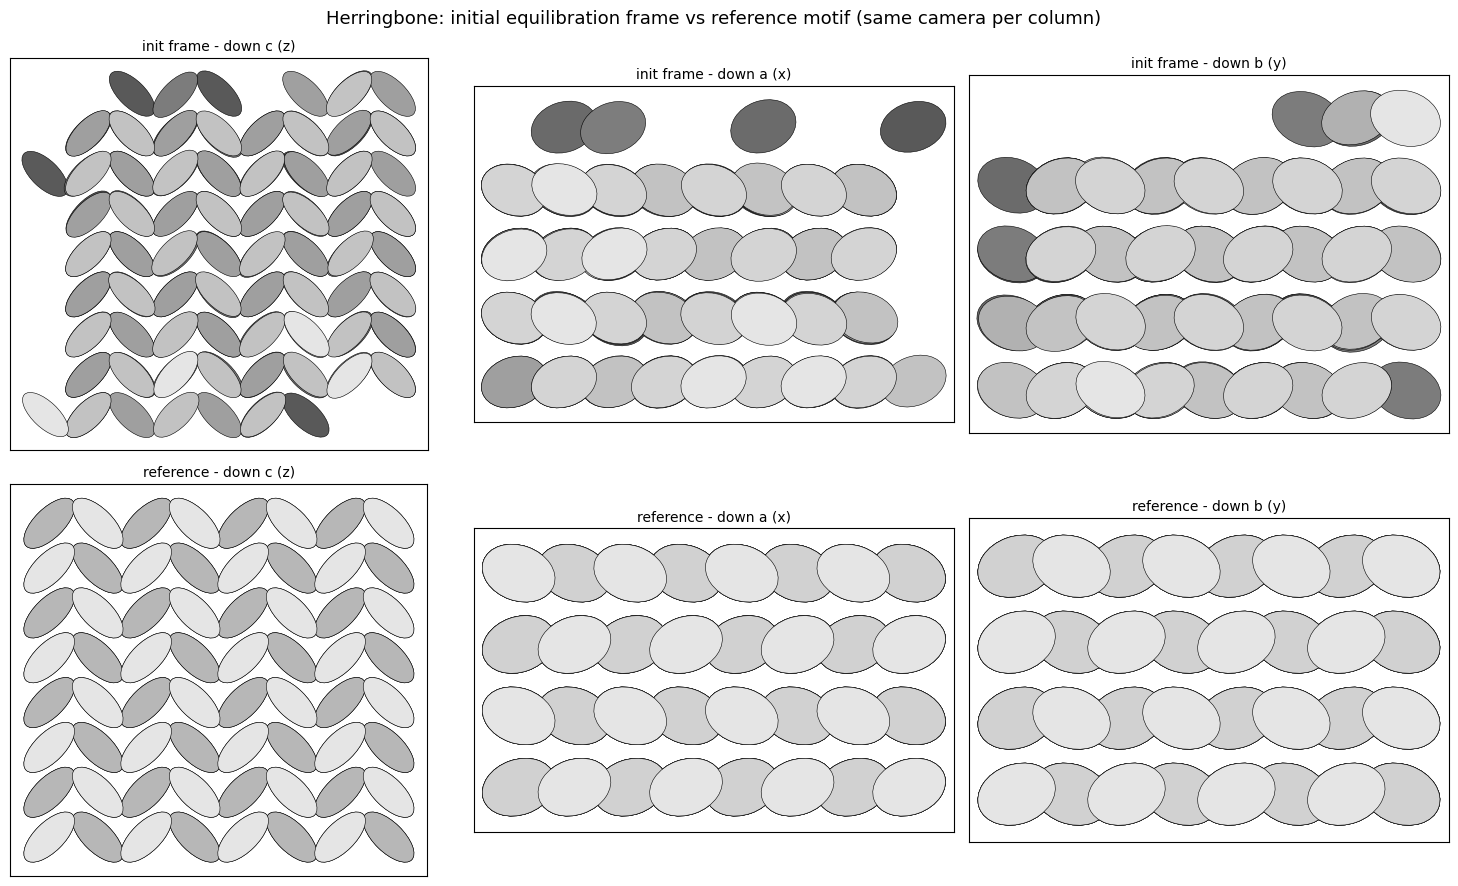

In [ ]:
# Herringbone sanity check: initial equilibration frame vs reference motif.
#
# Renders the first equilibration frame and the tiled reference
# benzene_herringbone_cg.xyz from identical viewpoints (one camera per column).
# The particles are oblate discs (or_vec = the short normal) whose normals lie
# ~in the a-b plane, so they read as a herringbone zigzag looking down c but as
# stacked discs from the side -- the two OVITO images were the SAME lattice from
# different cameras. If each column matches top-vs-bottom, the init is faithful.
from scipy.spatial.transform import Rotation
from matplotlib.patches import Ellipse
from asmcmc.initialize import _load_herringbone_motif, _herringbone_reps

RENDER_DIR = "../results/validation/100.0_6.324209e-07/herringbone"
DISC_AXES = np.array([2.5, 2.5, 1.0])  # oblate semi-axes; or_vec is the short (1.0) axis


def draw_frame(ax, positions, c_q, view, axes=DISC_AXES, title=""):
    """Draw each oblate particle as its projected silhouette (an ellipse) looking
    along `view`. Particles are depth-sorted back-to-front and shaded by depth."""
    v = np.asarray(view, float)
    v = v / np.linalg.norm(v)
    up = np.array([0.0, 0.0, 1.0]) if abs(v[2]) < 0.9 else np.array([1.0, 0.0, 0.0])
    e1 = np.cross(up, v); e1 /= np.linalg.norm(e1)
    e2 = np.cross(v, e1)
    basis = np.vstack([e1, e2])                                     # 2x3: plane perp to view
    rot = Rotation.from_quat(np.roll(c_q, -1, axis=1)).as_matrix()  # scalar-first -> scalar-last
    center = positions @ basis.T
    depth = positions @ v
    shade = (depth - depth.min()) / (np.ptp(depth) + 1e-9)
    for i in np.argsort(depth):                                     # back to front
        shape = basis @ (rot[i] @ np.diag(axes**2) @ rot[i].T) @ basis.T
        eigval, eigvec = np.linalg.eigh(shape)
        width, height = 2.0 * np.sqrt(np.maximum(eigval, 1e-9))
        angle = np.degrees(np.arctan2(eigvec[1, 1], eigvec[0, 1]))
        g = 0.35 + 0.55 * shade[i]
        ax.add_patch(Ellipse(center[i], width, height, angle=angle,
                             facecolor=(g, g, g), edgecolor="k", lw=0.4))
    pad = 3.0
    ax.set_xlim(center[:, 0].min() - pad, center[:, 0].max() + pad)
    ax.set_ylim(center[:, 1].min() - pad, center[:, 1].max() + pad)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)


# frame 1: my first equilibration frame (init + one MC block, so slightly thermal)
with connect(f"{RENDER_DIR}/equilibration.db") as db:
    row = next(db.select())
init_atoms = row.toatoms()
init_atoms.wrap()  # tuck PBC strays back in
init_pos = init_atoms.get_positions()
init_cq = np.asarray(row.data["c_q"])

# frame 2: reference benzene_herringbone_cg.xyz tiled to the same supercell
coms0, or0, cq0, edges = _load_herringbone_motif()
nx, ny, nz = _herringbone_reps(len(init_pos), edges)
a, b, c = edges
offsets = np.array([[i * a, j * b, k * c]
                    for i in range(nx) for j in range(ny) for k in range(nz)])
ref_pos = (coms0[None] + offsets[:, None]).reshape(-1, 3)
ref_cq = np.broadcast_to(cq0, (nx * ny * nz, len(cq0), 4)).reshape(-1, 4).copy()

VIEWS = [([0, 0, 1], "down c (z)"), ([1, 0, 0], "down a (x)"), ([0, 1, 0], "down b (y)")]
fig, axs = plt.subplots(2, len(VIEWS), figsize=(5 * len(VIEWS), 9))
for col, (view, name) in enumerate(VIEWS):
    draw_frame(axs[0, col], init_pos, init_cq, view, title=f"init frame - {name}")
    draw_frame(axs[1, col], ref_pos, ref_cq, view, title=f"reference - {name}")
fig.suptitle("Herringbone: initial equilibration frame vs reference motif "
             "(same camera per column)", fontsize=13)
fig.tight_layout()
fig.savefig(f"{RENDER_DIR}/herringbone_init_vs_reference.png", dpi=150)
plt.show()

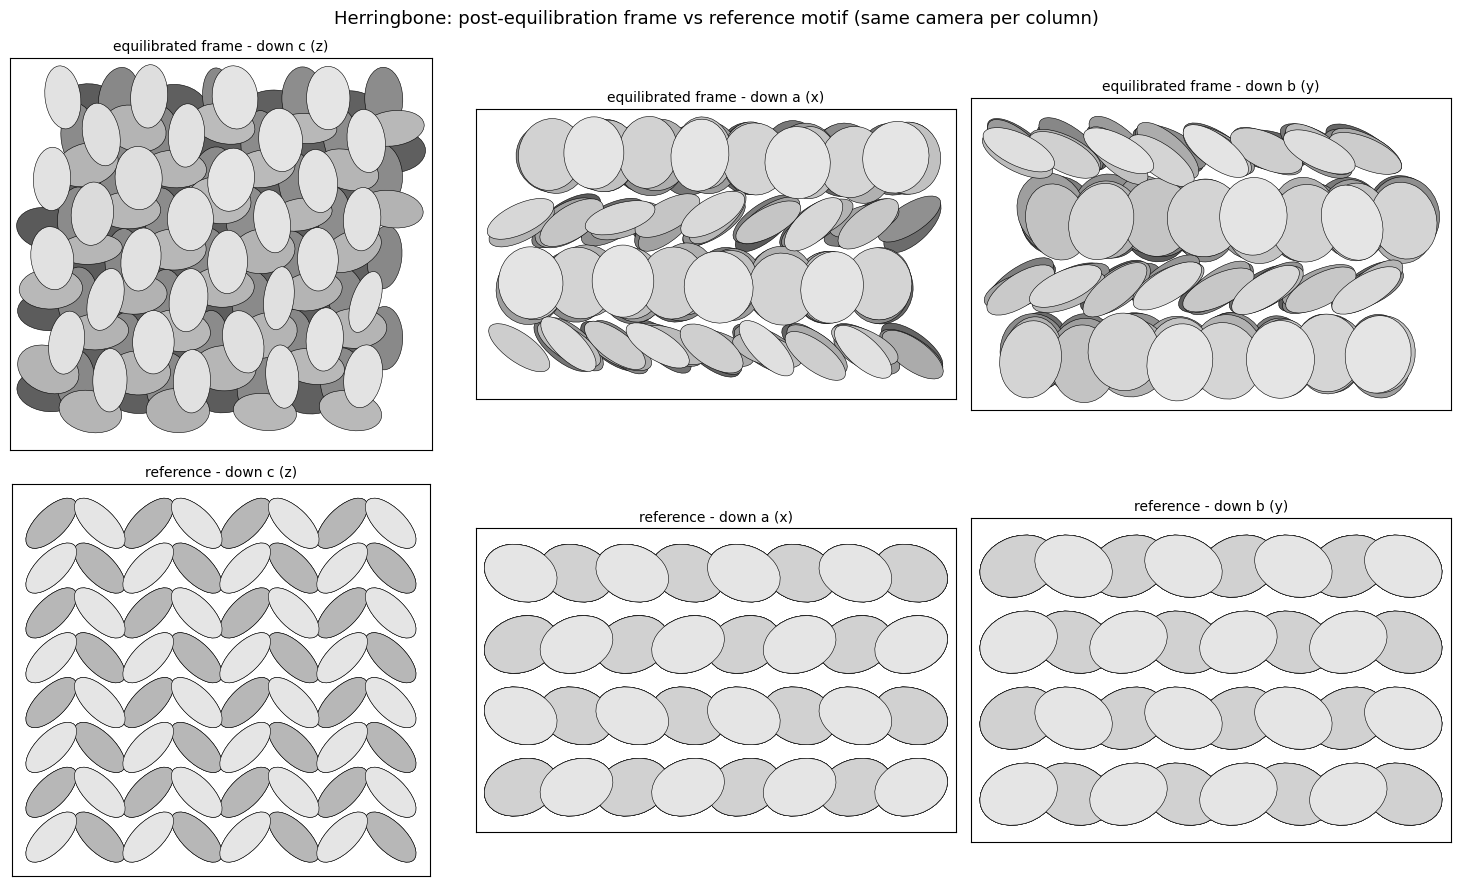

In [ ]:
# frame 1: my first simulation frame 
with connect(f"{RENDER_DIR}/simulation.db") as db:
    row = next(db.select())
init_atoms = row.toatoms()
init_atoms.wrap()  # tuck PBC strays back in
init_pos = init_atoms.get_positions()
init_cq = np.asarray(row.data["c_q"])

# frame 2: reference benzene_herringbone_cg.xyz tiled to the same supercell
coms0, or0, cq0, edges = _load_herringbone_motif()
nx, ny, nz = _herringbone_reps(len(init_pos), edges)
a, b, c = edges
offsets = np.array([[i * a, j * b, k * c]
                    for i in range(nx) for j in range(ny) for k in range(nz)])
ref_pos = (coms0[None] + offsets[:, None]).reshape(-1, 3)
ref_cq = np.broadcast_to(cq0, (nx * ny * nz, len(cq0), 4)).reshape(-1, 4).copy()

VIEWS = [([0, 0, 1], "down c (z)"), ([1, 0, 0], "down a (x)"), ([0, 1, 0], "down b (y)")]
fig, axs = plt.subplots(2, len(VIEWS), figsize=(5 * len(VIEWS), 9))
for col, (view, name) in enumerate(VIEWS):
    draw_frame(axs[0, col], init_pos, init_cq, view, title=f"equilibrated frame - {name}")
    draw_frame(axs[1, col], ref_pos, ref_cq, view, title=f"reference - {name}")
fig.suptitle("Herringbone: post-equilibration frame vs reference motif "
             "(same camera per column)", fontsize=13)
fig.tight_layout()
fig.savefig(f"{RENDER_DIR}/herringbone_post_equilibration.png", dpi=150)
plt.show()

In [9]:
RUN_DIR = "../results/validation/100.0_6.324209e-07/herringbone"

# Pull the state point straight from the run's write-once config so the
# measurements stay consistent with how the trajectory was generated.
with open(f"{RUN_DIR}/run_config.json") as f:
    config = json.load(f)

temp = config["temp"]
pressure = config["pressure"]
n_particles = config["init"]["init_n_particles"]

In [10]:
# Read measurements from pickle file on disk.  
# If this file doesn't exist, use ../scripts/single_state_run_hb_1atm.py to generate it

results_path = f"{RUN_DIR}/measurements.pkl"

with open(results_path, "rb") as f:
    results = pickle.load(f)
print(f"Loaded cached results from {results_path}")

Loaded cached results from ../results/validation/100.0_6.324209e-07/herringbone/measurements.pkl


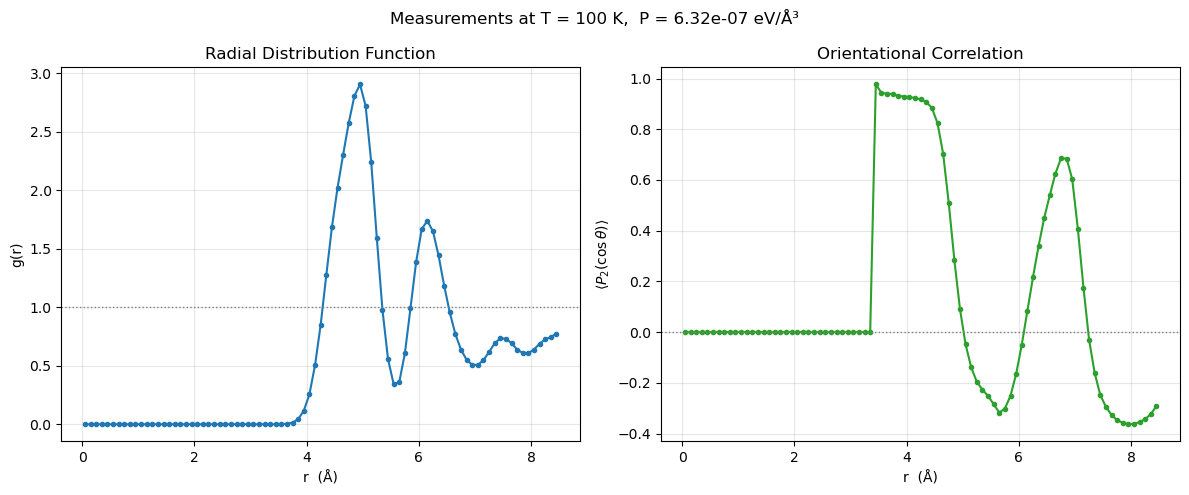

Nematic order:  S = 0.068 ± 0.009  (S_lab = 0.067)
Director:       [-1.    -0.005 -0.002]
Enthalpy:       H = -28.711 ± 0.181 eV   (H/N = -0.2243 eV)
Heat capacity:  C_p = 5.566e-04 eV/K/particle  (6.46 k_B/particle)


In [11]:
# Generate plots for RDF and OCF

rdf = results["rdf"]
ocf = results["ocf"]
nematic = results["nematic"]
H_mean, H_std = results["enthalpy"]
cp = results["heat_capacity"]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Radial distribution function g(r): positional order
axs[0].plot(rdf["r"], rdf["g_r"], marker=".")
axs[0].axhline(1.0, color="gray", ls=":", lw=1)
axs[0].set_xlabel("r  (Å)")
axs[0].set_ylabel("g(r)")
axs[0].set_title("Radial Distribution Function")

# Orientational correlation <P2(cos θ)>(r): neighbour alignment vs separation
axs[1].plot(ocf["r"], ocf["s2_r"], marker=".", color="tab:green")
axs[1].axhline(0.0, color="gray", ls=":", lw=1)
axs[1].set_xlabel("r  (Å)")
axs[1].set_ylabel(r"$\langle P_2(\cos\theta)\rangle$")
axs[1].set_title("Orientational Correlation")

for ax in axs:
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Measurements at T = {temp:g} K,  P = {pressure:.3g} eV/Å³")
fig.tight_layout()

# fig.savefig(f"{RUN_DIR}/measurements.png", dpi=150)

plt.show()

# Scalar observables
print(f"Nematic order:  S = {nematic['S']:.3f} ± {nematic['S_std']:.3f}  (S_lab = {nematic['S_lab']:.3f})")
print(f"Director:       {np.array2string(nematic['director'], precision=3)}")
print(f"Enthalpy:       H = {H_mean:.3f} ± {H_std:.3f} eV   (H/N = {H_mean / n_particles:.4f} eV)")
print(f"Heat capacity:  C_p = {cp:.3e} eV/K/particle  ({cp / BOLTZCONST:.2f} k_B/particle)")

In [14]:
traj = ase.io.read("../results/validation/100.0_6.324209e-07/herringbone/simulation.xyz", ":")

In [15]:
a = cell_vecs = traj[-1].cell[0] / 4
b = cell_vecs = traj[-1].cell[1] / 4
c = cell_vecs = traj[-1].cell[2] / 2

print(a)
print(b)
print(c)

[6.3312524 0.        0.       ]
[0.         6.84588414 0.        ]
[0.         0.         8.75698101]


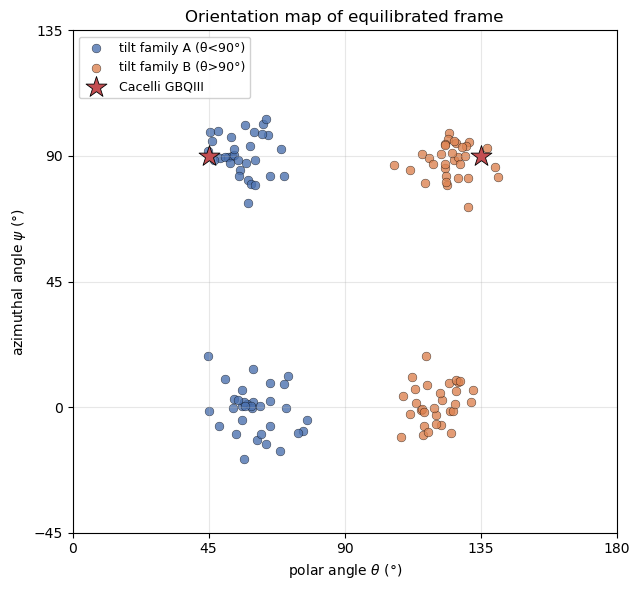

In [ ]:
# Molecular-orientation map of the last frame (inspired by Cacelli et al. 2004, Fig. 7b).
#
# The C6 axis is headless (u and -u are the same molecule), so we fold every
# normal into the u_y >= 0 half-sphere to kill the antipodal double-image.
#
# Wrapping psi into [-45, 135) moves the seam to the cluster midpoints and prevent splitting clusters in half

frame = traj[-1]
u = frame.get_array("or_vec").astype(float)
u = u / np.linalg.norm(u, axis=1, keepdims=True)

# fold headless axis: pick the representative with u_y >= 0 (tie-break on u_x)
flip = (u[:, 1] < 0) | ((u[:, 1] == 0) & (u[:, 0] < 0))
u[flip] *= -1.0

theta = np.degrees(np.arccos(np.clip(u[:, 2], -1.0, 1.0)))
psi = np.degrees(np.arctan2(u[:, 1], u[:, 0]))
psi = ((psi + 45.0) % 180.0) - 45.0  # move the fold seam off the x-domain -> [-45, 135)

# nematic order for the caption
Q = 1.5 * np.einsum("ni,nj->ij", u, u) / len(u) - 0.5 * np.eye(3)
S = np.linalg.eigvalsh(Q)[-1]

family = theta < 90.0  # the two mutually-perpendicular tilt families

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(theta[family], psi[family], s=40, alpha=0.8, edgecolor="k", lw=0.3,
           color="#4C72B0", label="tilt family A (θ<90°)")
ax.scatter(theta[~family], psi[~family], s=40, alpha=0.8, edgecolor="k", lw=0.3,
           color="#DD8452", label="tilt family B (θ>90°)")

# Cacelli GBQIII crystal reference: two spots at (45°, 90°) and (135°, 90°)
ax.scatter([45, 135], [90, 90], marker="*", s=250, color="#C44E52",
           edgecolor="k", lw=0.6, zorder=5, label="Cacelli GBQIII")

ax.set_xlim(0, 180)
ax.set_ylim(-45, 135)
ax.set_xticks(range(0, 181, 45))
ax.set_yticks(range(-45, 136, 45))
ax.set_xlabel(r"polar angle $\theta$ (°)")
ax.set_ylabel(r"azimuthal angle $\psi$ (°)")
ax.set_title(f"Orientation map of equilibrated frame")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, framealpha=0.9, loc="upper left")
fig.tight_layout()
fig.savefig(f"{RUN_DIR}/orientation_map.png", dpi=150)
plt.show()
